# **Import Libraries**

In [1]:
import os
import cv2
import torch
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

warnings.filterwarnings("ignore")

# **Step 2-Project Paths**

In [2]:
# ==========================
# Project Paths
# ==========================

MODEL_PATH = "../models/best.pt"

DATA_YAML = "../Dataset/data.yaml"

TEST_IMAGES = "../Dataset/test/images"

TEST_LABELS = "../Dataset/test/labels"

RESULTS_DIR = "../results/evaluation"

# **Step 3-Check Files**

In [3]:
print("="*60)
print("MODEL EVALUATION")
print("="*60)

print("Best Model Exists :", os.path.exists(MODEL_PATH))
print("Data YAML Exists  :", os.path.exists(DATA_YAML))
print("Test Images       :", os.path.exists(TEST_IMAGES))
print("Test Labels       :", os.path.exists(TEST_LABELS))

MODEL EVALUATION
Best Model Exists : True
Data YAML Exists  : True
Test Images       : True
Test Labels       : True


# **Step 4-Load Best Model**

In [4]:
MODEL_PATH = "../models/best.pt"
print("Best Model Loaded Successfully")

Best Model Loaded Successfully


# **Step 5 – Load Best Model**

In [5]:
from ultralytics import YOLO

model = YOLO(MODEL_PATH)

print("="*60)
print("MODEL LOADED SUCCESSFULLY")
print("="*60)

MODEL LOADED SUCCESSFULLY


# **Step 6-Evaluate Model on Test Set**

In [6]:
print("="*60)
print("MODEL EVALUATION")
print("="*60)

metrics = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=8,
    conf=0.25,
    iou=0.5,
    plots=True,
    save_json=True
)

MODEL EVALUATION
Ultralytics 8.4.112  Python-3.11.0 torch-2.13.0+cpu CPU (13th Gen Intel Core i7-1355U)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 237.6213.5 MB/s, size: 348.0 KB)
val: Scanning D:\Course\Deep Learning\AI-Road-Damage-Detection-System\Dataset\test\labels.cache... 5757 images, 1790 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5757/5757  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 720/720 1.2it/s 9:370.8ss
                   all       5757       9674      0.664      0.532      0.455       0.25
                   D00       2080       3925      0.654      0.506      0.429      0.239
                   D10       1117       1674      0.616      0.496      0.395      0.197
                   D20       1214       1537      0.717      0.571      0.515       0.27
                   D40       1100       1587      0.663      0.719    

# **Step 7-Display Evaluation Metrics**

In [7]:
print("="*60)
print("EVALUATION RESULTS")
print("="*60)

print(f"mAP@0.50      : {metrics.box.map50:.4f}")
print(f"mAP@0.50:0.95 : {metrics.box.map:.4f}")
print(f"Precision     : {metrics.box.mp:.4f}")
print(f"Recall        : {metrics.box.mr:.4f}")

EVALUATION RESULTS
mAP@0.50      : 0.4554
mAP@0.50:0.95 : 0.2495
Precision     : 0.6636
Recall        : 0.5320


# **Step 8 – Confusion Matrix**

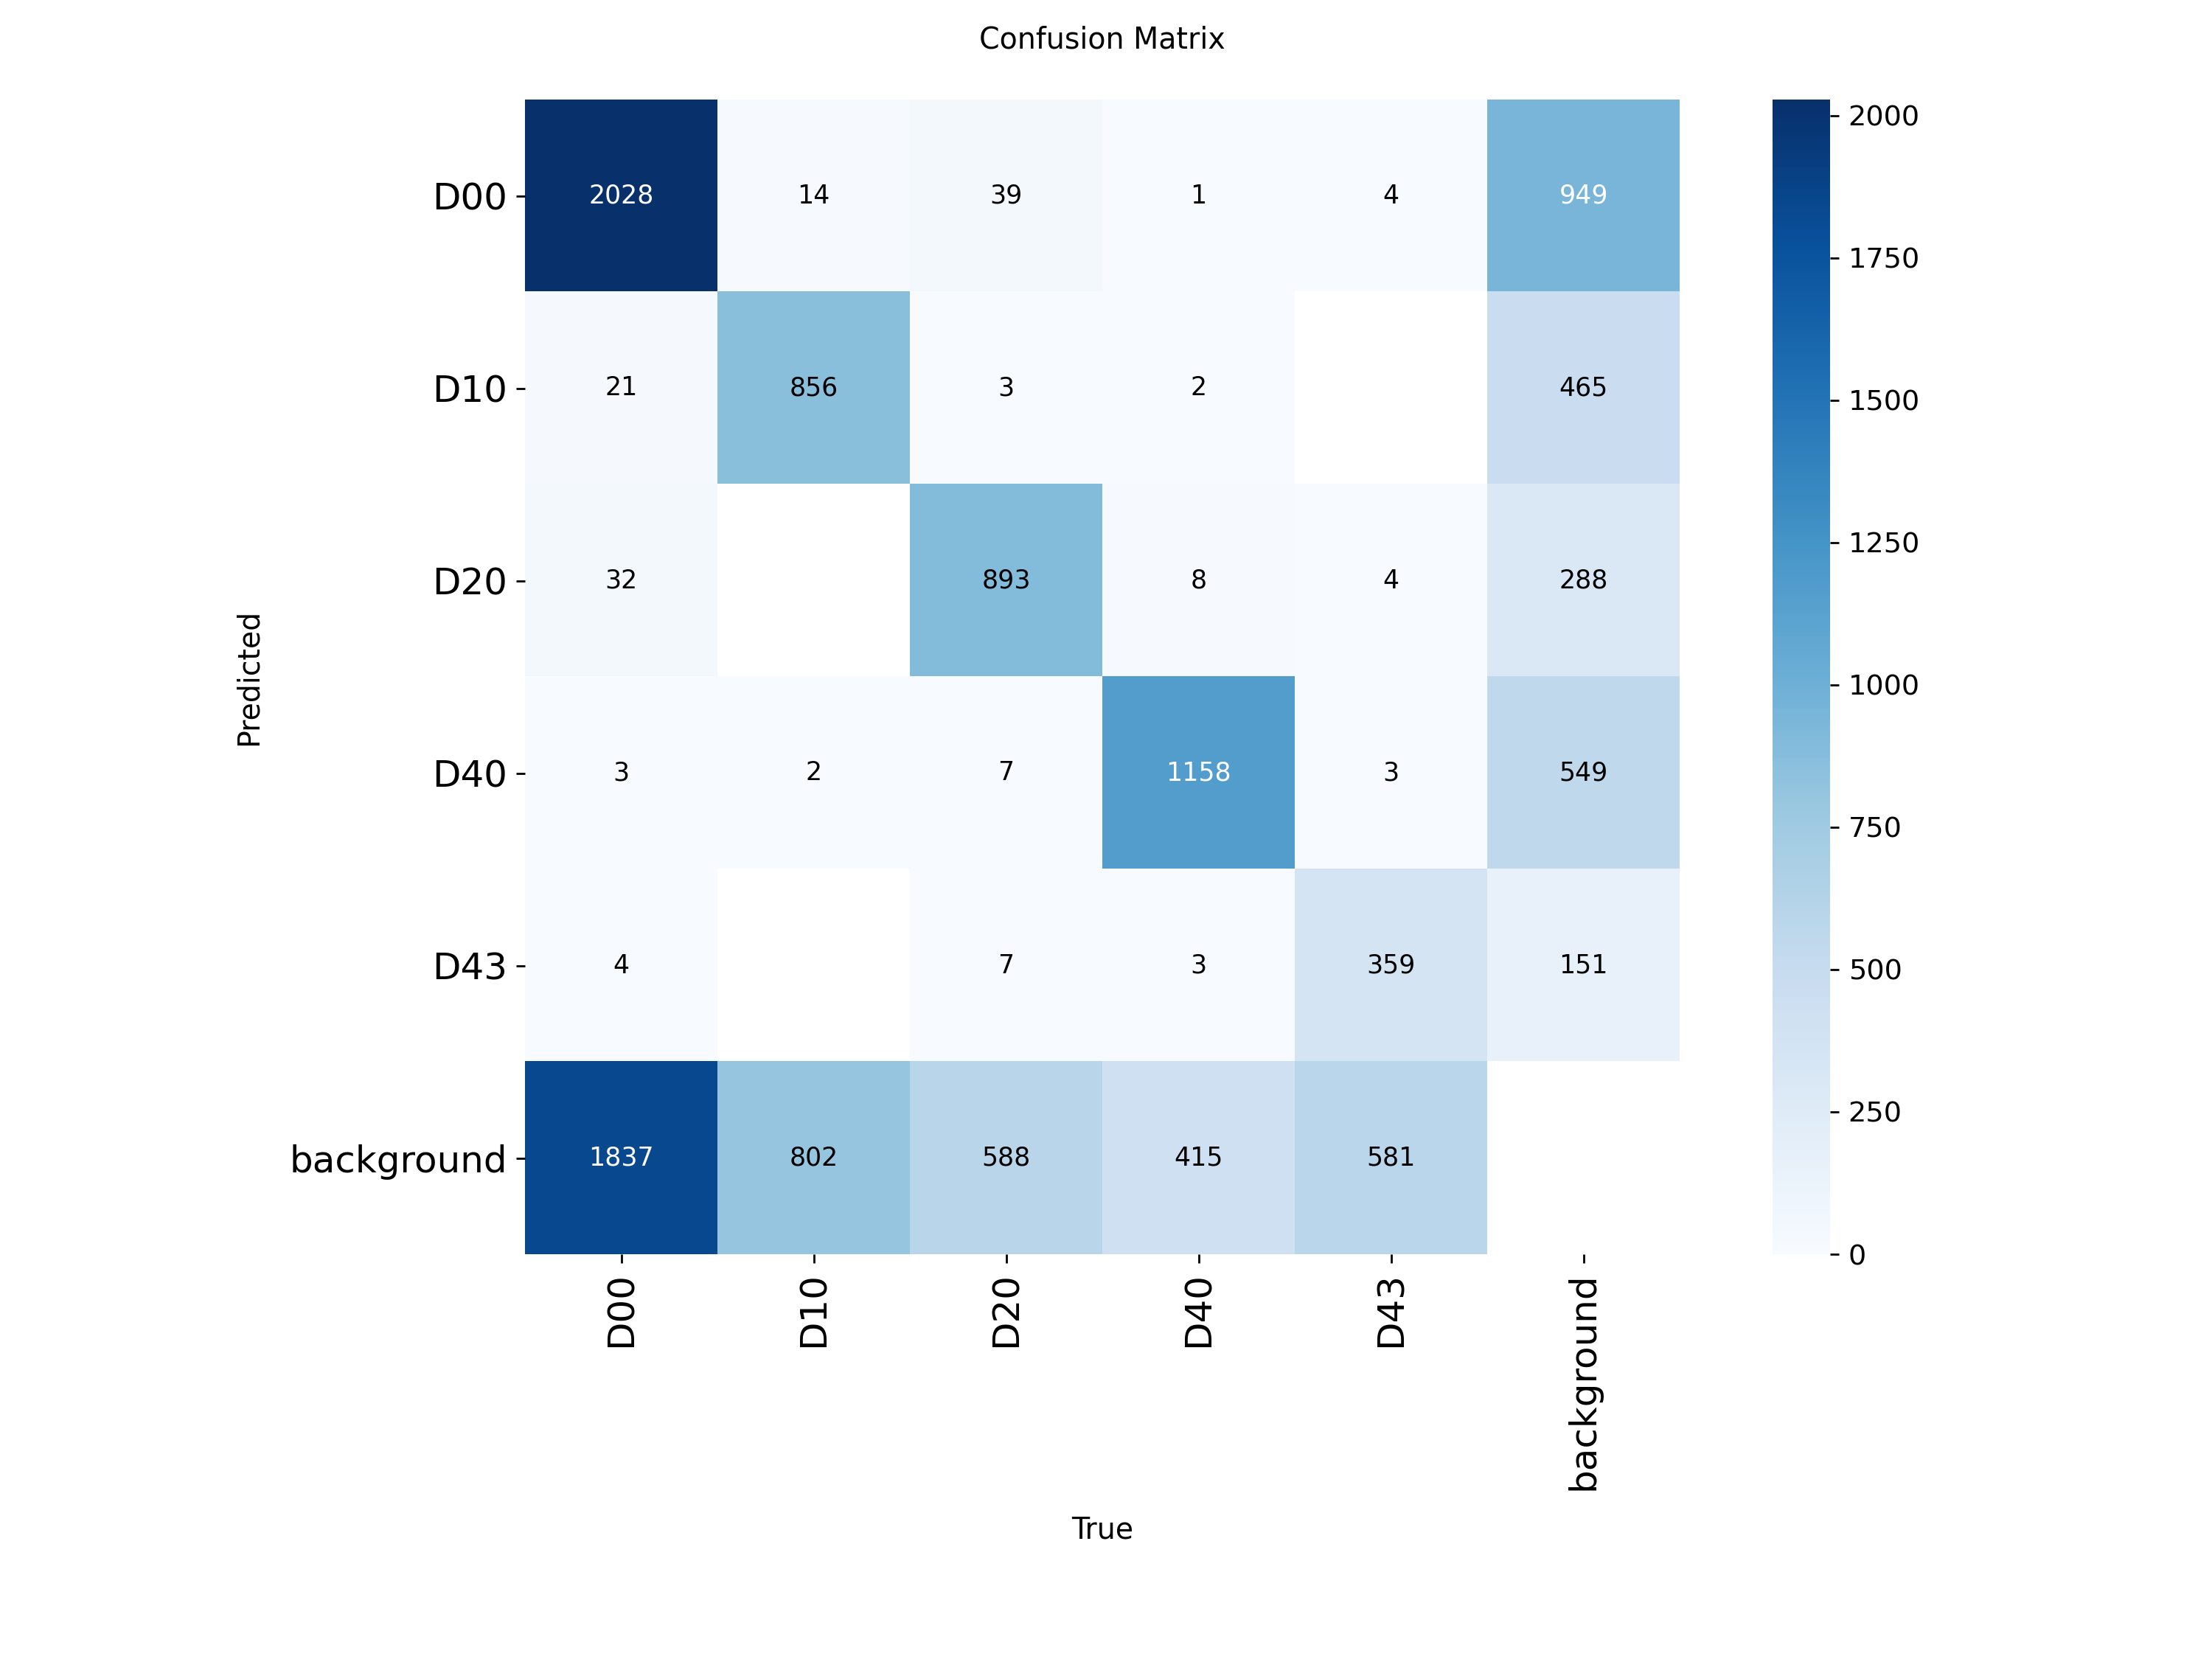

In [20]:
from IPython.display import Image, display
import os

conf_matrix = "runs/detect/val-2/confusion_matrix.png"

if os.path.exists(conf_matrix):
    display(Image(filename=conf_matrix))
else:
    print("Confusion Matrix not found.")

# **Step 9 – Precision Recall Curve**

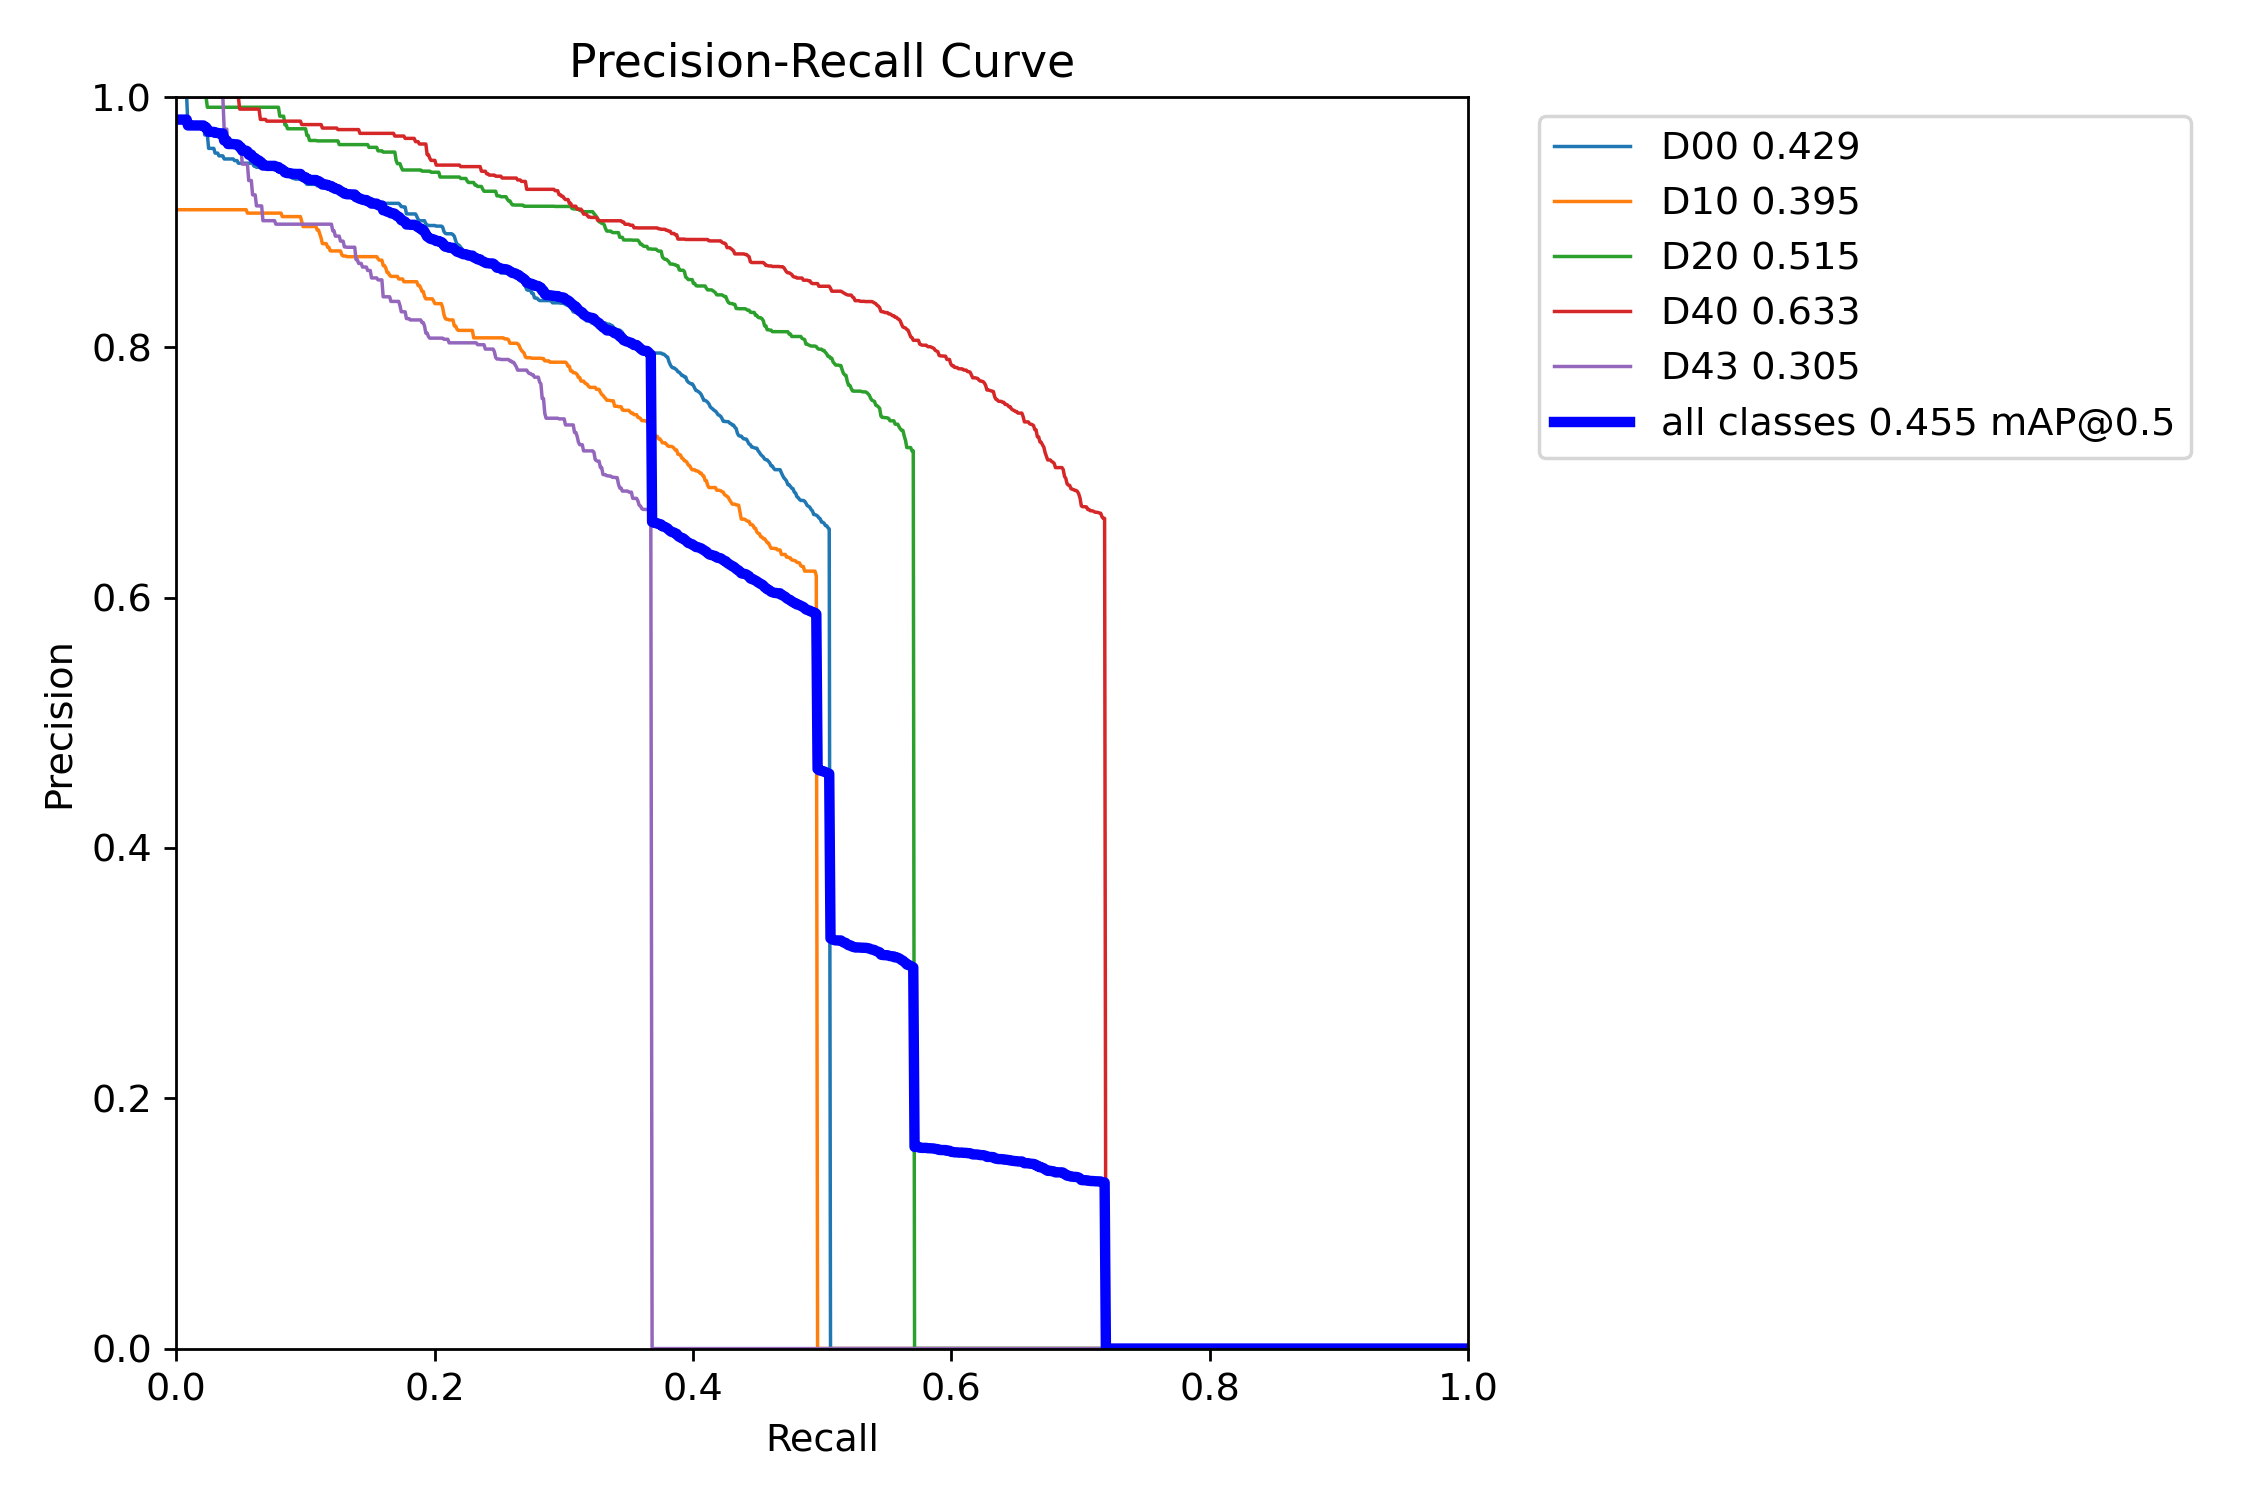

In [21]:
pr_curve = "runs/detect/val-2/BoxPR_curve.png"

if os.path.exists(pr_curve):
    display(Image(filename=pr_curve))
else:
    print("PR Curve not found.")

# **Step 10 – F1 Curve**

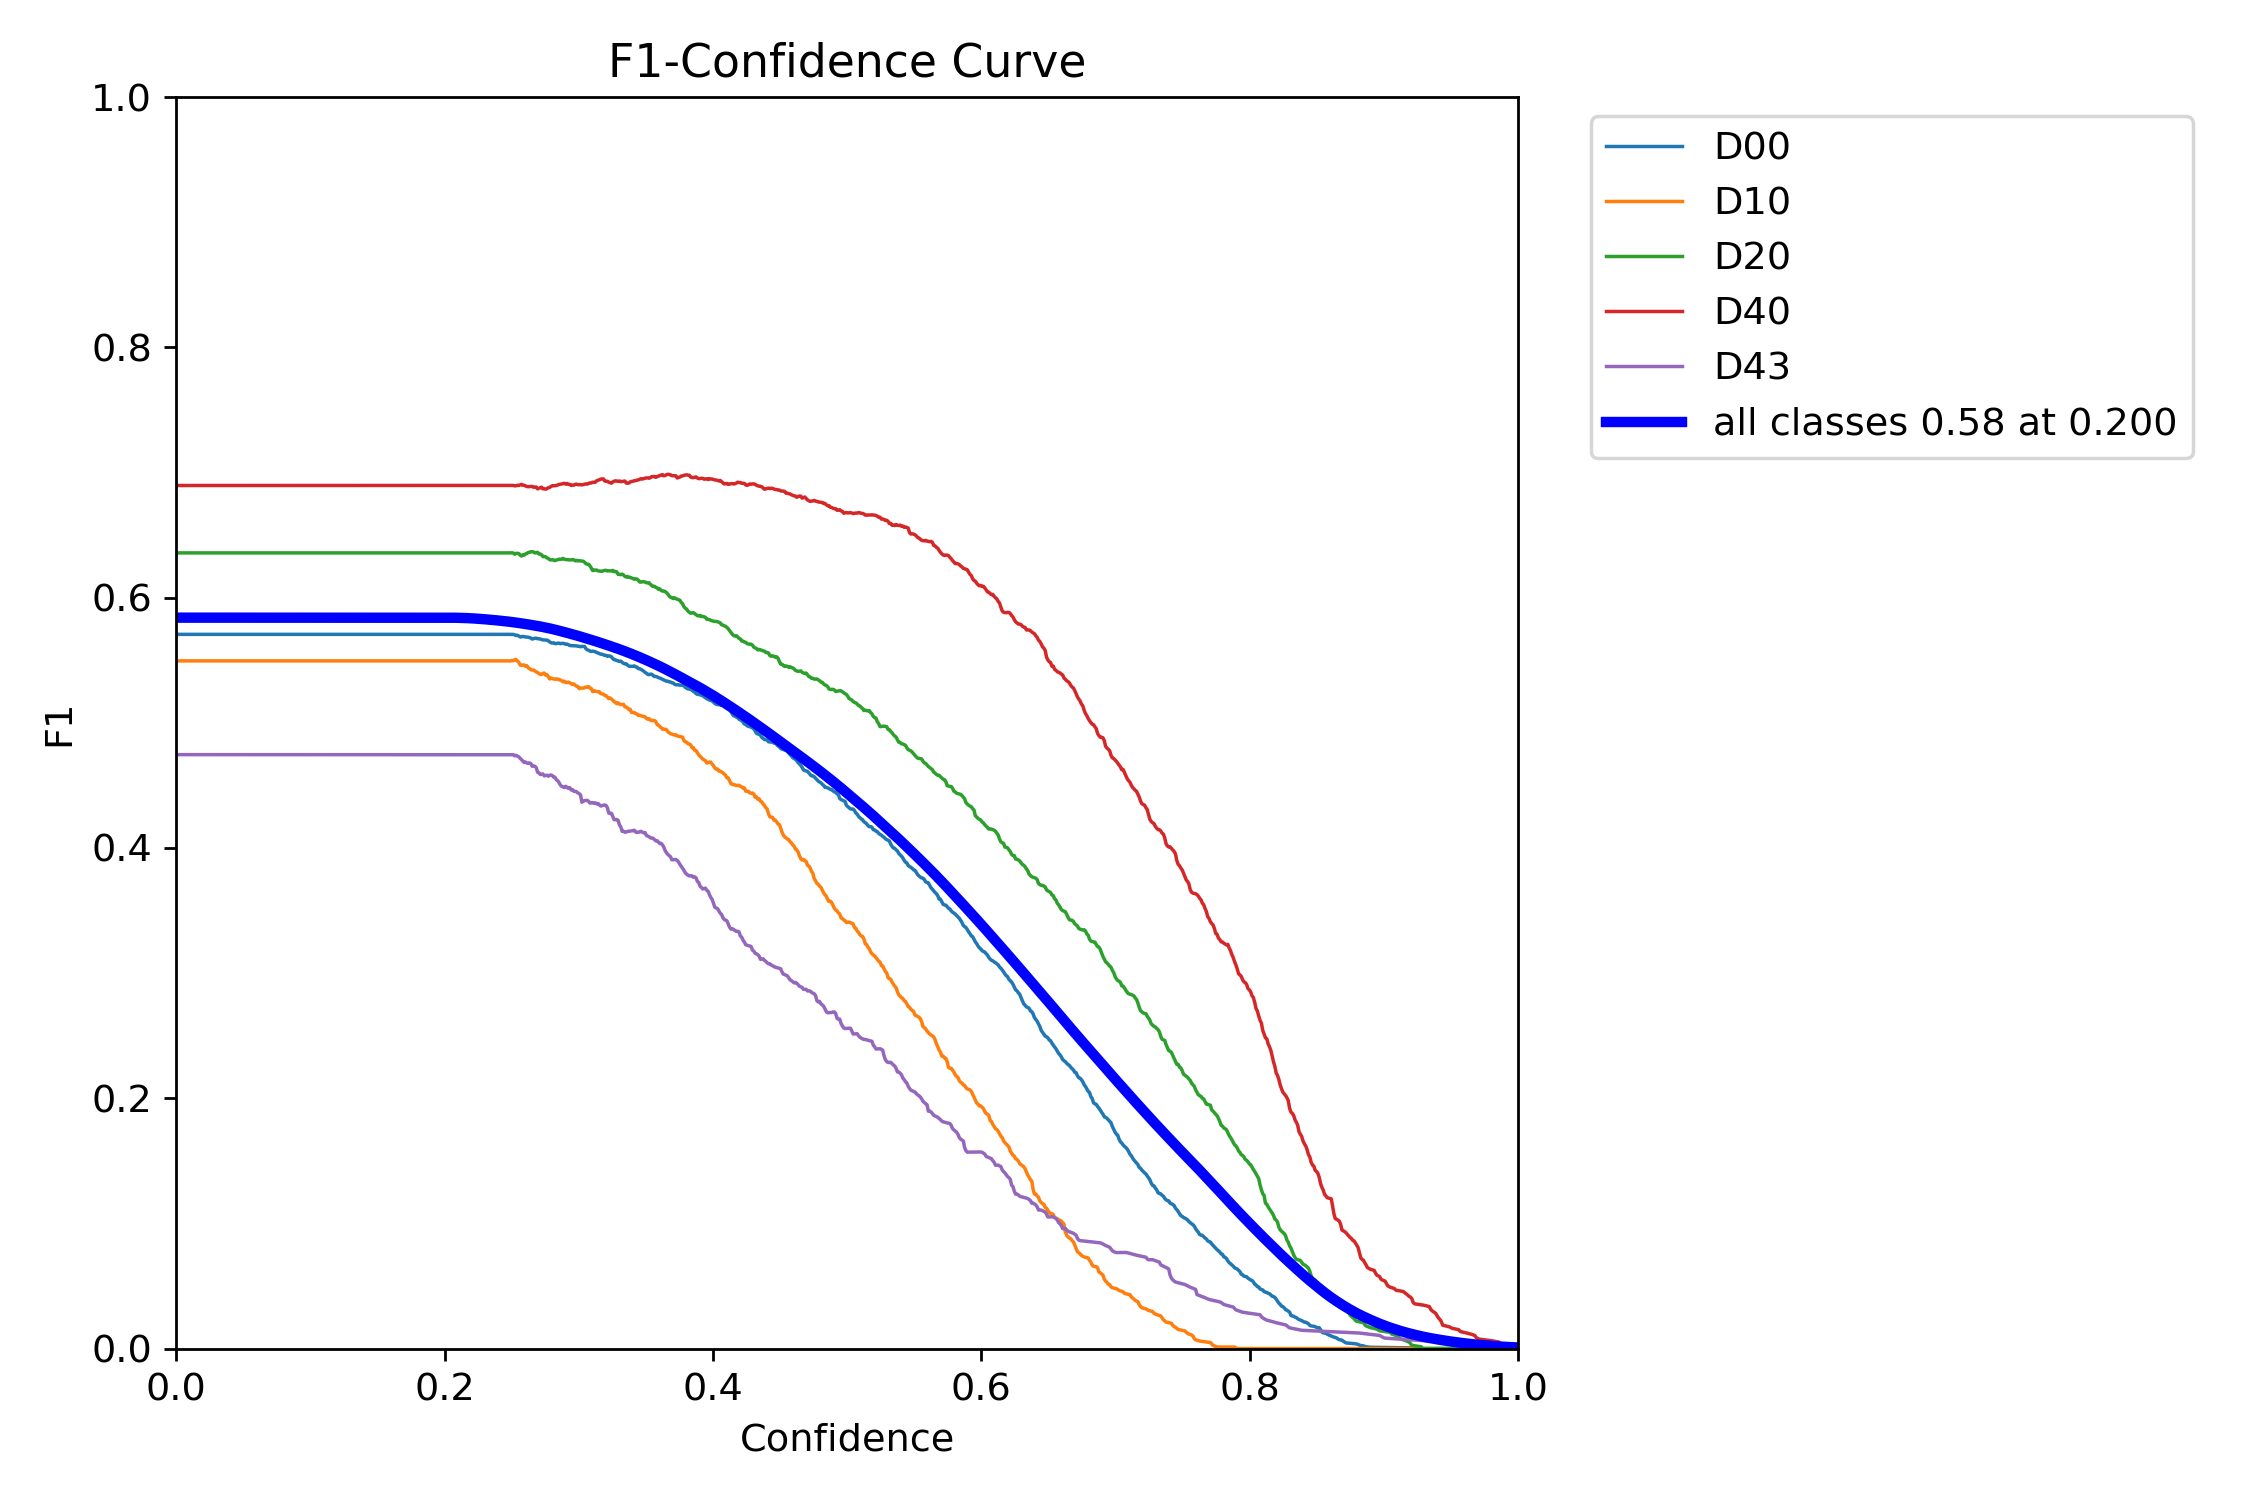

In [23]:
f1_curve = "runs/detect/val-2/BoxF1_curve.png"

if os.path.exists(f1_curve):
    display(Image(filename=f1_curve))
else:
    print("F1 Curve not found.")

# **Step 11 – Predictions on Random Test Images**

In [24]:
import random
import matplotlib.pyplot as plt

test_images = [os.path.join(TEST_IMAGES, x) for x in os.listdir(TEST_IMAGES)
               if x.endswith((".jpg", ".png", ".jpeg"))]

samples = random.sample(test_images, min(5, len(test_images)))

for img in samples:

    results = model.predict(
        source=img,
        conf=0.25,
        save=False
    )

    result_img = results[0].plot()

    plt.figure(figsize=(10,8))
    plt.imshow(result_img[:,:,::-1])
    plt.axis("off")
    plt.title(os.path.basename(img))
    plt.show()


image 1/1 d:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\..\Dataset\test\images\Norway_000863.jpg: 352x640 (no detections), 147.8ms
Speed: 10.3ms preprocess, 147.8ms inference, 2.5ms postprocess per image at shape (1, 3, 352, 640)


<Figure size 1000x800 with 1 Axes>


image 1/1 d:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\..\Dataset\test\images\Norway_002735.jpg: 384x640 (no detections), 45.1ms
Speed: 1.8ms preprocess, 45.1ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


<Figure size 1000x800 with 1 Axes>


image 1/1 d:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\..\Dataset\test\images\Norway_003001.jpg: 384x640 (no detections), 45.5ms
Speed: 2.0ms preprocess, 45.5ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


<Figure size 1000x800 with 1 Axes>


image 1/1 d:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\..\Dataset\test\images\India_000476.jpg: 640x640 (no detections), 73.7ms
Speed: 3.2ms preprocess, 73.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 1000x800 with 1 Axes>


image 1/1 d:\Course\Deep Learning\AI-Road-Damage-Detection-System\notebooks\..\Dataset\test\images\Japan_008019.jpg: 640x640 1 D00, 73.3ms
Speed: 3.9ms preprocess, 73.3ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 1000x800 with 1 Axes>

# **Step 12 – Final Summary**

In [25]:
print("="*70)
print("ROAD DAMAGE DETECTION MODEL EVALUATION COMPLETED")
print("="*70)

print(f"Precision     : {metrics.box.mp:.4f}")
print(f"Recall        : {metrics.box.mr:.4f}")
print(f"mAP@0.50      : {metrics.box.map50:.4f}")
print(f"mAP@0.50:0.95 : {metrics.box.map:.4f}")

print("="*70)
print("Evaluation Finished Successfully.")
print("="*70)

ROAD DAMAGE DETECTION MODEL EVALUATION COMPLETED
Precision     : 0.6636
Recall        : 0.5320
mAP@0.50      : 0.4554
mAP@0.50:0.95 : 0.2495
Evaluation Finished Successfully.


# **Step 13 – Save Evaluation Metrics**

In [26]:
import os

RESULTS_DIR = "../results/evaluation"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results directory created successfully!")

Results directory created successfully!


In [27]:
import pandas as pd
import os

os.makedirs(RESULTS_DIR, exist_ok=True)

evaluation_results = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "mAP@0.50",
        "mAP@0.50:0.95"
    ],
    "Value": [
        metrics.box.mp,
        metrics.box.mr,
        metrics.box.map50,
        metrics.box.map
    ]
})

evaluation_results.to_csv(
    os.path.join(RESULTS_DIR, "evaluation_metrics.csv"),
    index=False
)

evaluation_results

,Metric,Value
0,Precision,0.663565
1,Recall,0.532010
2,mAP@0.50,0.455432
3,mAP@0.50:0.95,0.249516


# **Step 14 – Save Model Summary**

In [28]:
summary_file = os.path.join(RESULTS_DIR, "evaluation_summary.txt")

with open(summary_file, "w") as f:

    f.write("="*60 + "\n")
    f.write("ROAD DAMAGE DETECTION MODEL EVALUATION\n")
    f.write("="*60 + "\n\n")

    f.write(f"Precision      : {metrics.box.mp:.4f}\n")
    f.write(f"Recall         : {metrics.box.mr:.4f}\n")
    f.write(f"mAP@0.50       : {metrics.box.map50:.4f}\n")
    f.write(f"mAP@0.50:0.95  : {metrics.box.map:.4f}\n")

print("Summary Saved Successfully.")

Summary Saved Successfully.


# **Step 15 – Display Saved Files**

In [29]:
print("="*60)
print("FILES GENERATED")
print("="*60)

for file in os.listdir(RESULTS_DIR):
    print(file)

FILES GENERATED
evaluation_metrics.csv
evaluation_summary.txt


# **Step 16 – Project Completed**

In [30]:
print("="*70)
print("ROAD DAMAGE DETECTION PROJECT COMPLETED")
print("="*70)

print("Dataset        : RDD2022")
print("Model          : YOLOv8")
print("Framework      : Ultralytics")
print("Evaluation     : Completed")
print("Results Saved  : Successfully")

print("="*70)
print("Thank You")
print("="*70)

ROAD DAMAGE DETECTION PROJECT COMPLETED
Dataset        : RDD2022
Model          : YOLOv8
Framework      : Ultralytics
Evaluation     : Completed
Results Saved  : Successfully
Thank You
